# Exploring the time before the events - history of rainfall and RH:

this notebook produces the following figures

- Figure 14

In [ ]:
import glob
import pandas as pd
import os
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import numpy as np
import matplotlib.colors
import cmocean
from scipy.interpolate import griddata
from matplotlib.dates import HourLocator
import matplotlib.dates as md
import datetime
import matplotlib.pyplot as plt
import math
from matplotlib import gridspec
from pathlib import Path
from matplotlib.colors import LogNorm, Normalize
import matplotlib as mpl

plt.rcParams["font.family"] = 'monospace'

In [39]:
def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

In [30]:
# Define paths relative to notebook location
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

In [3]:
dalmaso_loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\DalMaso_classification'
dalmaso_file = 'ZEP_class_DalMaso.txt'

ZEP_class = pd.read_csv(dalmaso_loadpath+'\\'+dalmaso_file, index_col=0, 
                        parse_dates=True)

event_type = 'Class Ia'
df_eventIa = ZEP_class[ZEP_class[event_type].notnull()]
event_daysIa = df_eventIa.index.unique()

event_type = 'Class Ib'
df_eventIb = ZEP_class[ZEP_class[event_type].notnull()]
event_daysIb = df_eventIb.index.unique()

event_type = 'Class II'
df_eventII = ZEP_class[ZEP_class[event_type].notnull()]
event_daysII = df_eventII.index.unique()

event_days = list(event_daysIa)+list(event_daysIb)+list(event_daysII)
print(len(event_days))

155


In [4]:
event_start_stop_loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\event_times'
event_start_stop_filename='events_start_and_end_times_checked.xlsx'

df_NPF_plusgrowth = pd.read_excel(event_start_stop_loadpath+'\\'+event_start_stop_filename, 
                                  index_col=0, parse_dates=True)
df_NPF_plusgrowth.index.name = 'event'

df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_event'].dt.date
df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_date'].astype(str)
df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_event'].dt.date
df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_date'].astype(str)

date='2022-04-18'
df_NPF_plusgrowth[df_NPF_plusgrowth['start_date'] == str(date)]
df_event_stats = df_NPF_plusgrowth.copy()

In [10]:
def create_traj_dictionary_using_matching_files(matching_list_of_back_traj_files, select_for_mixed_layer=True, traj_length=241,
                                                format_data='.pickle'):
    """an arrival time which maps to the trajectory dataset"""
    if select_for_mixed_layer == True:  
        print("mixed layer selected")
    trajs_dictionary = {}
    for traj_i in matching_list_of_back_traj_files: #each loaded traj_ds is quite long (a full year), so neetraj_ds to be separated  
        #print(traj_i)
        try:
            if format_data == '.dat':
                traj_ds = pd.read_csv(traj_i, parse_dates=['DateTime'], index_col=0) #cut the HYSPLIT using the index occurance of time_step = 0
            if format_data == '.pickle':
                print("file: "+str(traj_i))
                try:
                    traj_ds = pd.read_pickle(traj_i)
                except EOFError:                    
                    break
                traj_ds.index = pd.to_datetime(traj_ds.index)            
            arrival_time_of_traj = str(traj_ds.index[0])
            number_of_trajs = len(traj_ds.index.unique())          
            traj_ds = traj_ds[traj_ds['time_step'] > (traj_length)*(-1)]           
            if select_for_mixed_layer == True:               
                traj_ds = traj_ds[traj_ds['MIXDEPTH'] >= traj_ds['altitude']] #select for mixed-layer
            if len(traj_ds) > 0:             
                trajs_dictionary[str(arrival_time_of_traj)] = traj_ds 
        except IndexError:
            print("Index Error - end")
    trajs_dictionary
    return trajs_dictionary
       

In [13]:
def find_matching_files(list_of_HYSPLIT_files, HYSPLIT_names):
    """observation indexes we want to match with the list of HYSPLIT files"""
    matching_list_of_back_traj_files = [s for s in list_of_HYSPLIT_files if any(xs in s for xs in HYSPLIT_names)]
    print("Matching files from observational data & HYSPLIT: "+str(len(matching_list_of_back_traj_files)))
    return matching_list_of_back_traj_files

def list_files(year, inpath_processed_hysplit_dfs):
    """Find the a list of all the HYSPLIT files for a particular year"""
    list_of_files = glob.glob(inpath_processed_hysplit_dfs+str(year)+"\\"+'*')    
    return list_of_files

def create_HYSPLIT_name_from_list(list_indexes):
    """use the list of indexes and alter it for the format of HYSPLIT"""
    list_strings_indexes = [str(x) for x in list_indexes]
    list_strings_indexes = [x.replace('-','') for x in list_strings_indexes]
    list_strings_indexes = [x.replace(':','') for x in list_strings_indexes]
    list_strings_indexes = [x[:11] for x in list_strings_indexes]
    list_strings_indexes = [x.replace(' ','_') for x in list_strings_indexes]
    return list_strings_indexes

In [15]:
def produce_traj_dict_for_event(event, inpath_processed_hysplit_dfs="G:\\HYSPLIT\\processed\\",
                               traj_length=5*24, select_for_mixed_layer=True):   
    time_range = list(pd.date_range(event, event+pd.to_timedelta('1D'), freq='60Min')) #using time range
    #convert the datetimes to HYSPLIT names
    HYSPLIT_names_obs = create_HYSPLIT_name_from_list(time_range) #for whole period
    #list all the preprocessed HYSPLIT files - ones actually have preprocessed
    list_of_HYSPLIT_files = list_files(year=event.year, 
                                              inpath_processed_hysplit_dfs=inpath_processed_hysplit_dfs)
    #match the files with the datetimes interested
    matching_list_of_back_traj_files = find_matching_files(list_of_HYSPLIT_files, HYSPLIT_names_obs)
    #read in the matching files 
    trajs_dictionary = create_traj_dictionary_using_matching_files(matching_list_of_back_traj_files, 
                                                                          select_for_mixed_layer=select_for_mixed_layer, 
                                                                          traj_length=traj_length, format_data='.pickle')
    return trajs_dictionary

In [ ]:
def concat_cut_airmass_history(event_days, var, inpath_processed_hysplit_dfs, df_event_stats,
                               traj_length=5*24, select_for_mixed_layer=False, RH_limit=85):
    print(var)
    print(inpath_processed_hysplit_dfs)
    DFs = []
    for event in event_days:
        print(event)
        trajs_dictionary = produce_traj_dict_for_event(event, inpath_processed_hysplit_dfs=inpath_processed_hysplit_dfs,
                                        traj_length=traj_length, select_for_mixed_layer=select_for_mixed_layer)
        timesteps = np.arange(0, traj_length, 1)
        
        timesteps = [str(i) for i in timesteps]
        arrival_times = [*trajs_dictionary.keys()]    
        
        DF = pd.DataFrame(columns=['arrival_time']+timesteps)        
        DF['arrival_time'] = arrival_times
        DF = DF.set_index('arrival_time')

        for i, arrival_time in enumerate(arrival_times):
            df_traj = trajs_dictionary[arrival_time][['Traj_num', 'time_step', var]].copy()              
                        
            if var != 'RELHUMID':
                df_groupby = df_traj[df_traj[var] > 0].groupby(['time_step']).count()[var].sort_index(ascending=False).to_frame()
                print(df_groupby)
                df_groupby.index = df_groupby.index*(-1)
                timesteps = np.arange(0, traj_length, 1)
                df_groupby = df_groupby.reindex(timesteps, fill_value=0)
                df_groupby_count = df_traj.groupby(['time_step']).count()[var].sort_index(ascending=False).to_frame(name='count')
                df_groupby_count.index = df_groupby_count.index*(-1)
                df_groupby_norm = df_groupby.div(df_groupby_count['count'], axis=0)  
                values = df_groupby_norm.T.values[0]

                if len(values) == len(timesteps):
                    DF.loc[arrival_time] = values
                if len(values) != len(timesteps):
                    pass

            if var == 'RELHUMID':
                df_groupby = df_traj[df_traj[var] > RH_limit].groupby(['time_step']).count()[var].sort_index(ascending=False).to_frame()
                print(df_groupby)
                df_groupby.index = df_groupby.index*(-1)
                timesteps = np.arange(0, traj_length, 1)
                df_groupby = df_groupby.reindex(timesteps, fill_value=0)
                df_groupby_count = df_traj.groupby(['time_step']).count()[var].sort_index(ascending=False).to_frame(name='count')
                df_groupby_count.index = df_groupby_count.index*(-1)
                df_groupby_norm = df_groupby.div(df_groupby_count['count'], axis=0)  
                values = df_groupby_norm.T.values[0]

                if len(values) == len(timesteps):
                    DF.loc[arrival_time] = values
                if len(values) != len(timesteps):
                    pass

        if len(DF) > 0: 
            DF.index = pd.to_datetime(DF.index) 
            print(DF)
            DF = DF.sort_index()

            if event in set(df_event_stats.index):
                start_time = df_event_stats[df_event_stats.index == pd.to_datetime(event.date())].start_event.values[0]  
                end_time = df_event_stats[df_event_stats.index == pd.to_datetime(event.date())].end_event.values[0]
                DF.loc[DF.index < pd.to_datetime(start_time)] = np.nan #ignore all values before time of event
                DF.loc[pd.to_datetime(end_time) < DF.index] = np.nan
            
                DF = DF.dropna(how='all', axis=0)
                DF = DF.astype(float)
                DF = DF.reset_index()
                DF = DF.drop(columns='arrival_time')
                DFs.append(DF)
            
            if event not in set(df_event_stats.index):
                print("no info")
                pass


        else:
            pass
        
    return DFs    

In [ ]:
#this takes approximately 1m17.7s

inpath_processed_hysplit_dfs="E:\\HYSPLIT\\processed\\"

event_days = list(event_daysIa)+list(event_daysIb)
df_event_stats
var='RAINFALL'
traj_length=5*24
select_for_mixed_layer=False

DFs = concat_cut_airmass_history(event_days, var='RAINFALL', df_event_stats=df_event_stats,
                                 inpath_processed_hysplit_dfs=inpath_processed_hysplit_dfs) 

RAINFALL
E:\HYSPLIT\processed\
2022-04-21 00:00:00
Matching files from observational data & HYSPLIT: 25
file: E:\HYSPLIT\processed\2022\20220421_00.pickle
file: E:\HYSPLIT\processed\2022\20220421_01.pickle
file: E:\HYSPLIT\processed\2022\20220421_02.pickle
file: E:\HYSPLIT\processed\2022\20220421_03.pickle
file: E:\HYSPLIT\processed\2022\20220421_04.pickle
file: E:\HYSPLIT\processed\2022\20220421_05.pickle
file: E:\HYSPLIT\processed\2022\20220421_06.pickle
file: E:\HYSPLIT\processed\2022\20220421_07.pickle
file: E:\HYSPLIT\processed\2022\20220421_08.pickle
file: E:\HYSPLIT\processed\2022\20220421_09.pickle
file: E:\HYSPLIT\processed\2022\20220421_10.pickle
file: E:\HYSPLIT\processed\2022\20220421_11.pickle
file: E:\HYSPLIT\processed\2022\20220421_12.pickle
file: E:\HYSPLIT\processed\2022\20220421_13.pickle
file: E:\HYSPLIT\processed\2022\20220421_14.pickle
file: E:\HYSPLIT\processed\2022\20220421_15.pickle
file: E:\HYSPLIT\processed\2022\20220421_16.pickle
file: E:\HYSPLIT\processed\20

In [17]:
df_concatted = pd.concat(DFs)
df_average = df_concatted.groupby(df_concatted.index).mean()

In [19]:
def array_plot(array_2d, dfn2_4_hysplit=None, var='RAINFALL', num_ticks = 3, cmap=cmocean.cm.deep, interpolation='gaussian',
              vmax=0.03, title='', datetime_ticks=True, ymax=120, colorbar_title='Rainfall [mm/hr]',
              shrink=0.4, xmax=10):    
    height, width = array_2d.shape
    larger_dimension = int(max(height, width)/20)
    fig, ax = plt.subplots(figsize=(larger_dimension, larger_dimension))
    im = plt.imshow(array_2d, interpolation=interpolation, aspect='auto', origin='lower', cmap=cmap,
               vmin=0, vmax=vmax)
    cbar = plt.colorbar(im, orientation='vertical', location='right', anchor=(0, 0.5), shrink=shrink)
    cbar.set_label(colorbar_title, rotation=270, labelpad=12, fontsize=12)
    cbar.ax.tick_params(labelsize=15)    
    if title == None:
        date_title = str(pd.to_datetime(dfn2_4_hysplit.index.values[0]).date())
        plt.title(str(var)+'\n'+str(date_title))
    if title != None:
        plt.title(str(title))        
    plt.xlabel('h into event')
    plt.ylabel('h before arrival of airmass to receptor')    
    if datetime_ticks == True:
        dates = dfn2_4_hysplit.index.values
        date_format = DateFormatter('%Y-%m-%d')
        dates = [pd.to_datetime(date) for date in dates]
        hours_minutes = [date.strftime('%H:%M') for date in dates]    
        hours_minutes = [date.strftime('%Y-%m-%d %H:%M') for date in dates]    
        ax.set_xlabel('Datetime [hr]')    
        ax.xaxis.set_major_formatter(date_format)
        ticks = np.linspace(0, len(hours_minutes) - 1, num_ticks, dtype=int)
        plt.xticks(ticks, [hours_minutes[i] for i in ticks])
        plt.xticks(rotation=90)
    if datetime_ticks == False:
        hours = list(np.arange(0, 25, 1))
        ticks = np.linspace(0, 24 - 1, num_ticks, dtype=int)
        plt.xticks(ticks, [hours[i] for i in ticks])
    ax.plot(np.arange(0.5, 14.5), np.arange(0.5, 14.5), 'o-', c='r')
    plt.ylim(0, ymax)
    plt.xlim(0, xmax)
    plt.show()
    return fig

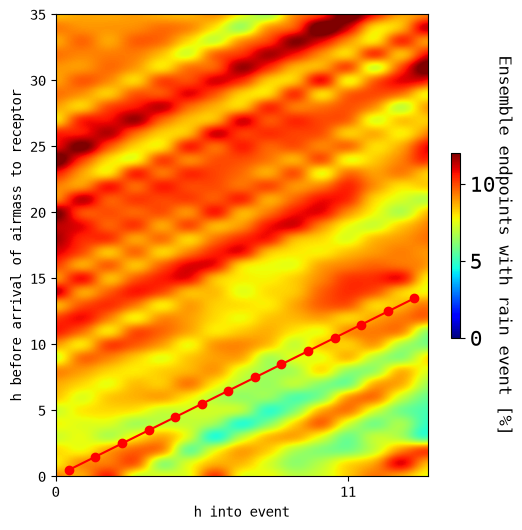

In [20]:
array_2d_RAINFALL = df_average.values.T 
fig = array_plot(array_2d_RAINFALL*100, dfn2_4_hysplit=None, vmax=12, datetime_ticks=False, ymax=35, xmax=14, 
                title='', colorbar_title='Ensemble endpoints with rain event [%]', cmap='jet', interpolation='gaussian')
plt.show()

In [21]:
DFs_RH = concat_cut_airmass_history(event_days, var='RELHUMID',
                                 inpath_processed_hysplit_dfs=inpath_processed_hysplit_dfs) 

RELHUMID
E:\HYSPLIT\processed\
2022-04-21 00:00:00
Matching files from observational data & HYSPLIT: 25
file: E:\HYSPLIT\processed\2022\20220421_00.pickle
file: E:\HYSPLIT\processed\2022\20220421_01.pickle
file: E:\HYSPLIT\processed\2022\20220421_02.pickle
file: E:\HYSPLIT\processed\2022\20220421_03.pickle
file: E:\HYSPLIT\processed\2022\20220421_04.pickle
file: E:\HYSPLIT\processed\2022\20220421_05.pickle
file: E:\HYSPLIT\processed\2022\20220421_06.pickle
file: E:\HYSPLIT\processed\2022\20220421_07.pickle
file: E:\HYSPLIT\processed\2022\20220421_08.pickle
file: E:\HYSPLIT\processed\2022\20220421_09.pickle
file: E:\HYSPLIT\processed\2022\20220421_10.pickle
file: E:\HYSPLIT\processed\2022\20220421_11.pickle
file: E:\HYSPLIT\processed\2022\20220421_12.pickle
file: E:\HYSPLIT\processed\2022\20220421_13.pickle
file: E:\HYSPLIT\processed\2022\20220421_14.pickle
file: E:\HYSPLIT\processed\2022\20220421_15.pickle
file: E:\HYSPLIT\processed\2022\20220421_16.pickle
file: E:\HYSPLIT\processed\20

In [22]:
df_concatted_RH = pd.concat(DFs_RH)
df_average_RH = df_concatted_RH.groupby(df_concatted_RH.index).mean()

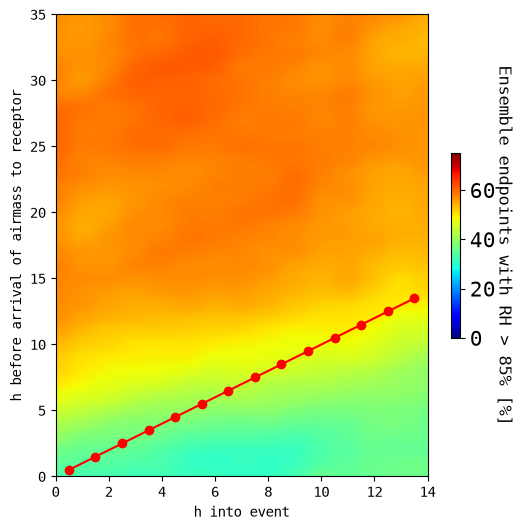

In [23]:
array_2d_RH = df_average_RH.values.T 
fig = array_plot(array_2d_RH*100, dfn2_4_hysplit=None, vmax=75, datetime_ticks=False, ymax=35, xmax=14, num_ticks = 12,
                title='', colorbar_title='Ensemble endpoints with RH > 85% [%]', cmap='jet', interpolation='gaussian')
plt.show()

In [24]:
def array_plot(array_2d, dfn2_4_hysplit=None, var='RAINFALL', num_ticks = 3, cmap=cmocean.cm.deep, interpolation='gaussian',
              vmax=0.03, title='', datetime_ticks=True, ymax=120, colorbar_title='Rainfall [mm/hr]',
              shrink=0.4, xmax=10, ylabel='Time before arrival of airmass to ZEP [h]', xlabel='Time into event [h]', ax=None):    
    height, width = array_2d.shape
    larger_dimension = int(max(height, width)/20)

    if ax == None:
        fig, ax = plt.subplots(figsize=(larger_dimension, larger_dimension))

    im = ax.imshow(array_2d, interpolation=interpolation, aspect='auto', origin='lower', cmap=cmap,
               vmin=0, vmax=vmax)
    
    if title == None:
        date_title = str(pd.to_datetime(dfn2_4_hysplit.index.values[0]).date())
        plt.title(str(var)+'\n'+str(date_title))
    if title != None:
        plt.title(str(title))
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    if datetime_ticks == True:
        dates = dfn2_4_hysplit.index.values
        date_format = DateFormatter('%Y-%m-%d')
        dates = [pd.to_datetime(date) for date in dates]
        hours_minutes = [date.strftime('%H:%M') for date in dates]    
        hours_minutes = [date.strftime('%Y-%m-%d %H:%M') for date in dates]    
        ax.set_xlabel('Datetime [hr]')    
        ax.xaxis.set_major_formatter(date_format)
        ticks = np.linspace(0, len(hours_minutes) - 1, num_ticks, dtype=int)
        plt.xticks(ticks, [hours_minutes[i] for i in ticks])
        plt.xticks(rotation=90)
    if datetime_ticks == False:
        hours = list(np.arange(0, 25, 1))
        ticks = np.linspace(0, 24 - 1, num_ticks, dtype=int)
        ax.set_xticks(ticks, [hours[i] for i in ticks])

    ax.plot(np.arange(0, 15.5), np.arange(0, 15.5), '--', lw=3, c='k')

    ax.set_ylim(0, ymax)
    ax.set_xlim(0, xmax)
  
    if ax == None:
        plt.show()
        return fig
    if ax != None:
        return ax

In [25]:
def angle(rng,point,x_fig,y_fig):
    '''
    This will return the alignment angle
    '''
    # print("rng = ", rng)
    x_scale = x_fig /(rng[1] - rng[0])
    y_scale = y_fig /(rng[3] - rng[2])
    assert len(point) == 2, 'point is not properly defined'
    x = point[0]
    y = point[1]
    rot = ((math.atan2( y*y_scale , x*x_scale ))*180)/math.pi
    print(rot,point)
    return rot

def center_point(start,end,height_offset):
    '''
    This will return the location of text placement
    '''
    x_mid = (end[0]-start[0])/2
    y_mid = (end[1]-start[1])/2
    return[x_mid+height_offset[0],y_mid+height_offset[1]]

In [26]:
def make_subplot_array_fig14(array_2d_RH, array_2d_RAINFALL):
    fig = plt.figure(figsize=(8, 4))
    gs = gridspec.GridSpec(ncols=8, nrows=1, hspace = .5, wspace=14, top = 1,
                            bottom = 0, left = 0, right = 1)
    ax1 = fig.add_subplot(gs[0:1, 0:4]) 
    array_plot(array_2d_RH*100, dfn2_4_hysplit=None, vmax=75, datetime_ticks=False, ymax=35, xmax=14.3, num_ticks=12,
                    title='', colorbar_title='Ensemble endpoints with RH > 85% [%]', cmap='jet', interpolation='gaussian', 
                    xlabel='', ax=ax1)
    cax = fig.add_subplot(gs[0:1, 3])
    create_colourbar(cax, vmin=0, vmax=75, cmap='jet', extend='max', 
                    colourbar_label='Ensemble endpoints with RH > 85% [%]', fontsize=12,
                    scientific_notation=False, log_scale=False, orientation='vertical', labels=None)
    vmax=12
    ax2 = fig.add_subplot(gs[0:1, 4:8]) 
    array_plot(array_2d_RAINFALL*100, dfn2_4_hysplit=None, vmax=vmax, datetime_ticks=False, ymax=35, xmax=14.3, num_ticks=12,
                    title='', colorbar_title='Ensemble endpoints with rain event [%]', cmap='jet', interpolation='gaussian', 
                    xlabel='', ylabel='', ax=ax2)
    cax = fig.add_subplot(gs[0:1, 7])
    create_colourbar(cax, vmin=0, vmax=vmax, cmap='jet', extend='max', 
                    colourbar_label='Ensemble endpoints with rain event [%]', fontsize=12,
                    scientific_notation=False, log_scale=False, orientation='vertical', labels=None)
    for axis in ['top','bottom','left','right']:
        ax1.spines[axis].set_linewidth(1.5)
        ax2.spines[axis].set_linewidth(1.5)
    fig.text(0.5, -0.1, 'Time into event [h]', ha='center', va='center')
    # I've used 3 plots here:
    x_range = [i for i in range(0,14)]
    y1_range = [i/1 for i in range(0,14)]
    offset = [0,1]
    # Plotting graphs...
    ax1.plot(x_range,y1_range,color='k', ls='--', label = '')
    rng = ax1.axis() # This gives the axes range
    rot_y1 = angle(rng,[x_range[-1],y1_range[-1]],3.5, 4)
    pos_y1 = center_point([x_range[0],y1_range[0]],[x_range[-1],y1_range[-1]], offset)
    ax1.annotate('NPF event 1:1 line', xy =(0, 0),
                    xytext =(pos_y1[0], pos_y1[1]), 
                    rotation=rot_y1)
    ax2.plot(x_range,y1_range,color='k', ls='--', label = '')
    rng = ax2.axis() # This gives the axes range
    rot_y1 = angle(rng,[x_range[-1],y1_range[-1]],3.5, 4)
    pos_y1 = center_point([x_range[0],y1_range[0]],[x_range[-1],y1_range[-1]], offset)
    ax2.annotate('NPF event 1:1 line', xy =(0, 0),
                    xytext =(pos_y1[0], pos_y1[1]), 
                    rotation=rot_y1)
    ax1.annotate('a)', xy =(0, 0),
                    xytext =(0.2,33.5))
    ax2.annotate('b)', xy =(0, 0),
                    xytext =(0.2,33.5))
    plt.show()
    return fig

In [ ]:
def create_colourbar(cax, vmin=10**(-1), vmax=10**4, cmap='jet', extend='both', 
                     colourbar_label=r'dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', fontsize=12,
                     scientific_notation=True, log_scale=True, orientation='vertical', labels=None):
    if log_scale == True:
        norm = LogNorm(vmin, vmax)
    if log_scale == False:
        norm=Normalize(vmin, vmax)
    fmt = None
    if cmap is None:
        cmap=mpl.colormaps.get_cmap('magma')
    if cmap is not None:
        cmap=mpl.colormaps.get_cmap(cmap)        
    if scientific_notation == True:
        fmt = ticker.ScalarFormatter(useMathText=True)
        fmt.set_powerlimits((-2, 4)) 
        
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation=orientation)
    cb.set_label(colourbar_label, fontsize=fontsize)
    cb.ax.tick_params(labelsize=fontsize)
    cb.ax.yaxis.set_offset_position('left')    
    cb.ax.yaxis.get_offset_text().set_fontsize(fontsize)    
    cb.update_ticks()
    
    if labels is not None:
        cb.set_ticklabels(labels)
        locs=[vmin, vmax]
        cb.set_ticks(locs)
        
    return cb     

25.02969471554578 [13, 13.0]
25.02969471554578 [13, 13.0]


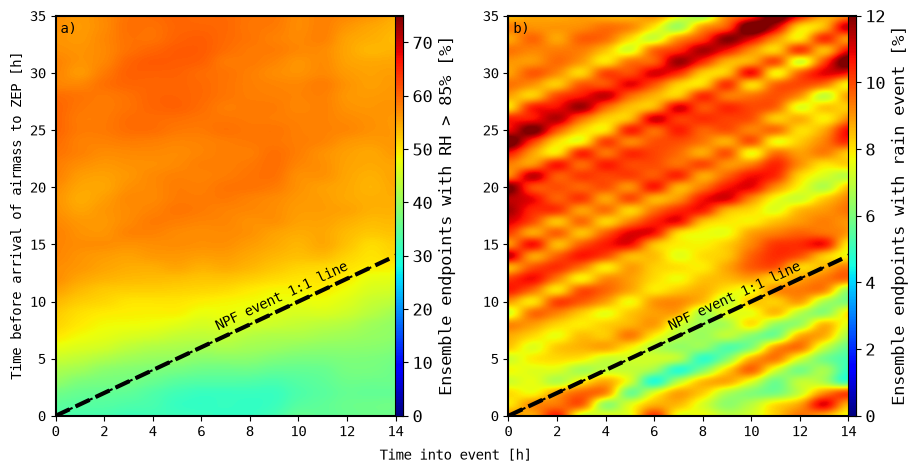

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_14.jpeg


In [40]:
fig = make_subplot_array_fig14(array_2d_RH, array_2d_RAINFALL)

output_figure = plots_outpath / 'Figure_14.jpeg'
save_plot(fig, output_figure)